# KLA - Baseline NAFNet Training

Degraded Input -> Normalisation -> Degradataion Encoder -> NAFNet -> Charbonnier loss

In [7]:
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
import sys
import time
import dataclasses
from pathlib import Path
from typing import Callable

import jax
import jax.numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
import grain
from flax import nnx
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


In [8]:
TRAIN_PATH = "./train"
TEST_PATH = "./NoisyLR"

TRAIN_LR_PATH = os.path.join(TRAIN_PATH, "NoisyLR")
TEST_LR_PATH = TEST_PATH
TRAIN_GT_PATH = os.path.join(TRAIN_PATH, "GT")


In [9]:
@dataclasses.dataclass
class TrainConfig:
    train_noisy_dir: str
    train_gt_dir: str
    batch_size: int = 8
    worker_count: int = 1
    seed: int = 42

    in_channels: int = 1
    out_channels: int = 1
    hidden_dim: int = 32
    num_blocks: int = 4
    upsample_scale: int = 2

    deg_hidden_dim: int = 16
    deg_embed_dim: int = 8

    normalization: str = "asinh"

    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    grad_clip_norm: float = 1.0

    num_epochs: int = 100
    val_split: float = 0.1

    ckpt_dir: str = "checkpoints"
    ckpt_every_epochs: int = 5
    max_to_keep: int = 5

    log_every_steps: int = 20
    loss_func: str = "Huber"


cfg = TrainConfig(
    train_noisy_dir=TRAIN_LR_PATH,
    train_gt_dir=TRAIN_GT_PATH,
    batch_size=16,
    hidden_dim=32,
    num_blocks=6,
    num_epochs=50,
    ckpt_dir="./checkpoints",
    ckpt_every_epochs=5,
)


In [10]:
from dataloader import create_src_dataloader


In [11]:
EPS = 1e-6


def zscore_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    mean = jnp.mean(x, axis=axis, keepdims=True)
    std = jnp.std(x, axis=axis, keepdims=True)
    return (x - mean) / (std + eps)


def zscore_denormalize(x_norm: jax.Array, mean: jax.Array, std: jax.Array, eps: float = EPS) -> jax.Array:
    return x_norm * (std + eps) + mean


def asinh_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    median = jnp.median(x, axis=axis, keepdims=True)
    q75 = jnp.quantile(x, 0.75, axis=axis, keepdims=True)
    q25 = jnp.quantile(x, 0.25, axis=axis, keepdims=True)
    iqr = q75 - q25
    return jnp.arcsinh((x - median) / (iqr + eps))


def asinh_denormalize(x_norm: jax.Array, median: jax.Array, iqr: jax.Array, eps: float = EPS) -> jax.Array:
    return jnp.sinh(x_norm) * (iqr + eps) + median


# Registry so the train script can select strategy by name from config,
# without importing every function individually.
NORMALIZERS: dict[str, Callable[..., jax.Array]] = {
    "zscore": zscore_normalize,
    "asinh": asinh_normalize,
    "none": lambda x, **kwargs: x,
}


def get_normalizer(name: str) -> Callable[..., jax.Array]:
    if name not in NORMALIZERS:
        raise ValueError(f"Unknown normalizer '{name}'. Options: {list(NORMALIZERS)}")
    return NORMALIZERS[name]


In [12]:
from model_util import (
    DegradationEncoder,
    SimpleGate,
    SimplifiedChannelAttention,
    FiLM,
    NAFBlock,
    PixelShuffle,
    BaselineNAFNet,
    RestorationPipeline,
    RestorationPipeline_2,
)

from train_utils import (
    charbonnier_loss_mean,
    compute_bicubic_upsample,
    to_device,
    train_step,
    val_step,
)


In [13]:
# ── File listing + train/val split ──────────────────────────────────────

all_noisy = sorted(Path(cfg.train_noisy_dir).glob("*.npy"))
all_gt    = sorted(Path(cfg.train_gt_dir).glob("*.npy"))
assert len(all_noisy) == len(all_gt), (
    f"Mismatch: {len(all_noisy)} noisy files vs {len(all_gt)} GT files"
)

train_noisy, val_noisy, train_gt, val_gt = train_test_split(
    all_noisy, all_gt,
    test_size=cfg.val_split, random_state=cfg.seed,
)

# ── Build dataloaders ───────────────────────────────────────────────────

train_src, train_loader = create_src_dataloader(
    train_noisy, train_gt,
    batch_size=cfg.batch_size, worker_count=cfg.worker_count,
    seed=cfg.seed, shuffle=True, augment=True,
)

val_src, val_loader = create_src_dataloader(
    val_noisy, val_gt,
    batch_size=cfg.batch_size, worker_count=cfg.worker_count,
    seed=cfg.seed + 1, shuffle=False, augment=False,
)

train_steps_per_epoch = len(train_src) // cfg.batch_size
val_steps_per_epoch   = len(val_src) // cfg.batch_size

print(f"Train: {len(train_src)} samples → {train_steps_per_epoch} steps/epoch")
print(f"Val:   {len(val_src)} samples → {val_steps_per_epoch} steps/epoch")


Train: 2880 samples → 180 steps/epoch
Val:   320 samples → 20 steps/epoch


In [14]:
def build_checkpoint_manager(ckpt_dir, max_to_keep=5):
    options = ocp.CheckpointManagerOptions(
        max_to_keep=max_to_keep,
        save_interval_steps=1,  
        create=True,
        enable_async_checkpointing=True,
    )
    ckpt_dir = Path(ckpt_dir).resolve()
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    return ocp.CheckpointManager(str(ckpt_dir), options=options)


def save_checkpoint(manager, step, model, optimizer, epoch, train_loss):
    _, model_state = nnx.split(model)
    _, opt_state = nnx.split(optimizer)
    metadata = {"epoch": epoch, "step": step, "train_loss": float(train_loss)}

    manager.save(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardSave(model_state),
            opt_state=ocp.args.StandardSave(opt_state),
            metadata=ocp.args.JsonSave(metadata),
        ),
    )


def restore_checkpoint(manager, step, model, optimizer):
    _, abstract_model_state = nnx.split(nnx.eval_shape(lambda: model))
    _, abstract_opt_state = nnx.split(nnx.eval_shape(lambda: optimizer))

    restored = manager.restore(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardRestore(abstract_model_state),
            opt_state=ocp.args.StandardRestore(abstract_opt_state),
            metadata=ocp.args.JsonRestore(),
        ),
    )
    nnx.update(model, restored.model_state)
    nnx.update(optimizer, restored.opt_state)
    return dict(restored.metadata)

In [17]:
rngs = nnx.Rngs(cfg.seed)
model = RestorationPipeline(
    in_channels=cfg.in_channels, out_channels=cfg.out_channels, hidden_dim=cfg.hidden_dim,
    num_blocks=cfg.num_blocks, upsample_scale=cfg.upsample_scale,
    deg_hidden_dim=cfg.deg_hidden_dim, deg_embed_dim=cfg.deg_embed_dim, rngs=rngs,
)

warmup = 2000
total_train_steps = train_steps_per_epoch * cfg.num_epochs

schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=cfg.learning_rate,
    warmup_steps=warmup, decay_steps=total_train_steps - warmup, end_value=1e-6,
)

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(cfg.grad_clip_norm),
        optax.adamw(learning_rate=schedule, weight_decay=cfg.weight_decay),
    ),
    wrt=nnx.Param,
)

normalizer_fn = asinh_normalize

ckpt_manager = build_checkpoint_manager(cfg.ckpt_dir, max_to_keep=cfg.max_to_keep)
print(f"[hardware] backend={jax.default_backend()} devices={jax.devices()}")
print(f"[schedule] warmup={warmup}  total_steps={total_train_steps}")


[hardware] backend=cpu devices=[CpuDevice(id=0)]
[schedule] warmup=2000  total_steps=9000


In [16]:
train_iter = iter(train_loader)
val_iter   = iter(val_loader)
global_step = 0

for epoch in range(cfg.num_epochs):
    epoch_start = time.time()

    # ── Train ─────────────────────────────────────────────────────────
    model.train()
    epoch_train_losses = []
    pbar = tqdm(range(train_steps_per_epoch), desc=f"Epoch {epoch:03d} [train]", leave=False)
    for step_in_epoch in pbar:
        raw_batch = to_device(next(train_iter))

        # --- preprocessing (outside JIT) ---
        noisy = raw_batch["noisy_lr"].astype(jnp.float32)

        gt    = raw_batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))

        loss = train_step(model, optimizer, x_norm, gt)
        epoch_train_losses.append(float(loss))
        global_step += 1

        pbar.set_postfix(loss=f"{float(loss):.5f}")

    train_loss_mean = float(np.mean(epoch_train_losses))

    # ── Validate ──────────────────────────────────────────────────────
    model.eval()
    epoch_val_losses = []
    pbar_val = tqdm(range(val_steps_per_epoch), desc=f"Epoch {epoch:03d} [val]  ", leave=False)
    for _ in pbar_val:
        raw_batch = to_device(next(val_iter))

        noisy = raw_batch["noisy_lr"].astype(jnp.float32)
        gt    = raw_batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))

        v_loss, _ = val_step(model, x_norm, gt)
        epoch_val_losses.append(float(v_loss))

        pbar_val.set_postfix(val_loss=f"{float(v_loss):.5f}")

    val_loss_mean = float(np.mean(epoch_val_losses))

    # ── Epoch summary ─────────────────────────────────────────────────
    epoch_time = time.time() - epoch_start
    print(
        f"[epoch {epoch:03d}] "
        f"train_loss={train_loss_mean:.5f}  "
        f"val_loss={val_loss_mean:.5f}  "
        f"time={epoch_time:.1f}s"
    )

    if (epoch + 1) % cfg.ckpt_every_epochs == 0 or epoch == cfg.num_epochs - 1:
        save_checkpoint(ckpt_manager, global_step, model, optimizer, epoch, train_loss_mean)
        print(f"  [checkpoint] saved at step {global_step} (epoch {epoch})")

ckpt_manager.wait_until_finished()
ckpt_manager.close()
print("[done] training complete.")


Epoch 000 [train]:   0%|          | 0/180 [00:00<?, ?it/s]

Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Traceback (most recent call last):
  File "/home/aneesh_shastri/miniforge3/envs/ml_env/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/aneesh_shastri/miniforge3/envs/ml_env/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/aneesh_shastri/miniforge3/envs/ml_env/lib/python3.11/site-packages/grain/_src/python/dataset/transformations/process_prefetch.py", line 251, in _put_dataset_elements_in_buffer
    if not grain_queue.add_element_to_queue(  # pytype: disable=wrong-arg-types
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/aneesh_shastri/miniforge3/envs/ml_env/lib/python3.11/site-packages/grain/_src/python/ipc/queue.py", line 54, in add_element_to_queue
    elements_queue.put(element, timeout=_QUEUE_WAIT_TIMEOUT_SECONDS)
  File "/home/aneesh_shastr

KeyboardInterrupt: 

In [18]:

from train_utils import metric_val_step
restore_checkpoint(ckpt_manager,step=9000,model=model,optimizer=optimizer)

model.eval()
final_metrics=[]
SSIM_metric=[]
PSNR_metric=[]
LPIPS_metric=[]
pbar_val = tqdm(range(val_steps_per_epoch), desc=f"Epoch {epoch:03d} [val]  ", leave=False)
for _ in pbar_val:
    raw_batch = to_device(next(val_iter))

    noisy = raw_batch["noisy_lr"].astype(jnp.float32)
    gt    = raw_batch["gt"].astype(jnp.float32)
    x_norm = normalizer_fn(noisy, axis=(1, 2))
    metrics, _ = metric_val_step(model, x_norm, gt)
    SSIM_metric.append(metrics['SSIM'])
    PSNR_metric.append(metrics['PSNR'])
    LPIPS_metric.append(metrics['LPIPS'])
    final_metrics.append(metrics)

print(f"mean SSIM:{np.mean(SSIM_metric)}")
print(f"mean PSNR:{np.mean(PSNR_metric)}")
print(f"mean LPIPS:{np.mean(LPIPS_metric)}")

ValueError: Topology mismatch detected. The checkpoint was saved with a different topology than the current one. Please provide a target tree with the desired topology to restore.

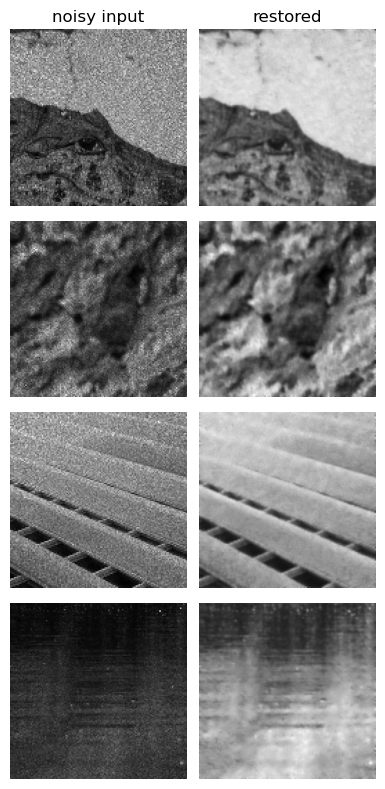

In [ ]:
import matplotlib.pyplot as plt

test_files = sorted(Path(TEST_LR_PATH).glob("*.npy"))[:8]
test_imgs = np.stack([np.load(f) for f in test_files])[..., None].astype(np.float32)  # (N,H,W,1)

# --- preprocessing (outside JIT) ---
noisy = to_device({"noisy_lr": test_imgs})["noisy_lr"]
x_norm = normalizer_fn(noisy, axis=(1, 2))

pred, _z_d = model(x_norm)

n = min(4, len(test_files))
fig, ax = plt.subplots(n, 2, figsize=(4, 2 * n))
for i in range(n):
    ax[i, 0].imshow(noisy[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["noisy input", "restored"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()


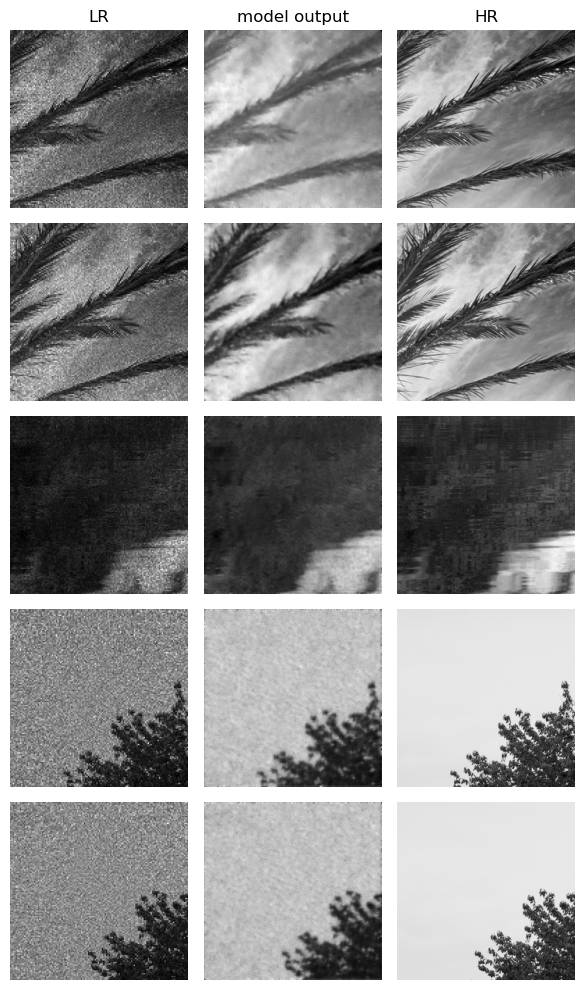

In [ ]:
lr_files = sorted(Path(TRAIN_LR_PATH).glob("*.npy"))[10:15]
gt_files = sorted(Path(TRAIN_GT_PATH).glob("*.npy"))[10:15]

lr_imgs = np.stack([np.load(f) for f in lr_files])[..., None].astype(np.float32)
hr_imgs = np.stack([np.load(f) for f in gt_files])[..., None].astype(np.float32)

# --- preprocessing (outside JIT) ---
lr = to_device({"noisy_lr": lr_imgs})["noisy_lr"]
hr = to_device({"gt": hr_imgs})["gt"]
x_norm = normalizer_fn(lr, axis=(1, 2))

pred, _z_d = model(x_norm)

n = len(lr_files)
fig, ax = plt.subplots(n, 3, figsize=(6, 2 * n))
for i in range(n):
    ax[i, 0].imshow(lr[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
    ax[i, 2].imshow(hr[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["LR", "model output", "HR"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()
